In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [2]:
with open('../outputs/semantic_clustering/semantic_clustering_scores.json', 'r') as f:
    data = json.load(f)

scores = np.array([r['score'] for r in data])
labels = np.array([r['label'] for r in data])

print(f"Questions: {len(data)}")
print(f"Hallucinated: {labels.sum()} | Factual: {(labels == 0).sum()}")
print(f"Score range: {scores.min():.4f} – {scores.max():.4f}")

Questions: 817
Hallucinated: 408 | Factual: 409
Score range: 0.0000 – 2.9264


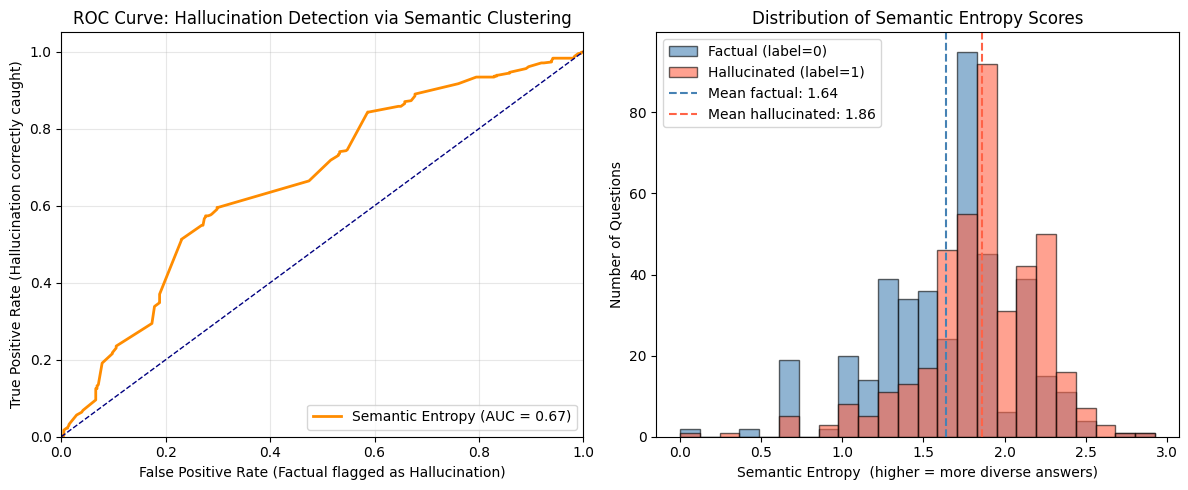

AUROC: 0.6655
Mean score — Hallucinated: 1.8609 | Factual: 1.6365


In [3]:
fpr, tpr, _ = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

hallucinated_scores = scores[labels == 1]
factual_scores = scores[labels == 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- ROC Curve ---
ax = axes[0]
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'Semantic Entropy (AUC = {roc_auc:.2f})')
ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (Factual flagged as Hallucination)')
ax.set_ylabel('True Positive Rate (Hallucination correctly caught)')
ax.set_title('ROC Curve: Hallucination Detection via Semantic Clustering')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

# --- Score Distribution ---
ax = axes[1]
bins = np.linspace(scores.min(), scores.max(), 25)
ax.hist(factual_scores, bins=bins, alpha=0.6, color='steelblue', edgecolor='black', label='Factual (label=0)')
ax.hist(hallucinated_scores, bins=bins, alpha=0.6, color='tomato', edgecolor='black', label='Hallucinated (label=1)')
ax.axvline(factual_scores.mean(), color='steelblue', linestyle='dashed', linewidth=1.5, label=f'Mean factual: {factual_scores.mean():.2f}')
ax.axvline(hallucinated_scores.mean(), color='tomato', linestyle='dashed', linewidth=1.5, label=f'Mean hallucinated: {hallucinated_scores.mean():.2f}')
ax.set_title('Distribution of Semantic Entropy Scores')
ax.set_xlabel('Semantic Entropy  (higher = more diverse answers)')
ax.set_ylabel('Number of Questions')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/semantic_clustering/semantic_clustering_analysis.png', dpi=300)
plt.show()

print(f"AUROC: {roc_auc:.4f}")
print(f"Mean score — Hallucinated: {hallucinated_scores.mean():.4f} | Factual: {factual_scores.mean():.4f}")